In [55]:
# Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

Found cached dataset csv (C:/Users/theim/.cache/huggingface/datasets/lukebarousse___csv/lukebarousse--data_jobs-20095235c13fb98d/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1)


  0%|          | 0/1 [00:00<?, ?it/s]

In [56]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

In [57]:
df_skills = df_DA.explode('job_skills')

In [78]:
skills_count = df_skills.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skill_count=('salary_year_avg', 'size')
).sort_values(by='skill_count', ascending=False).head(10)

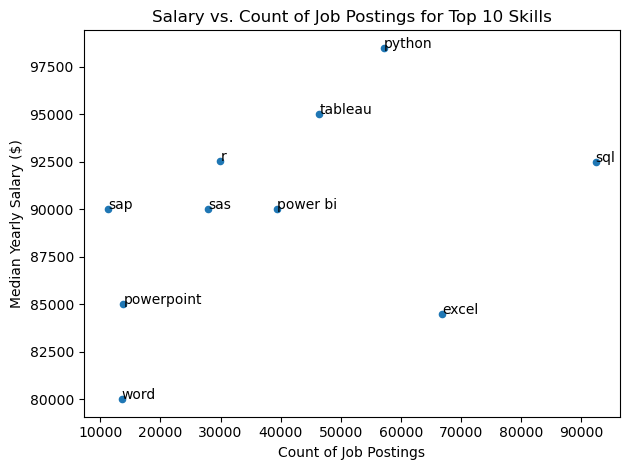

In [86]:
skills_count.plot(kind='scatter', x='skill_count', y='median_salary')

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($)')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.tight_layout()

for i, txt in enumerate(skills_count.index):
    plt.text(
        skills_count['skill_count'].iloc[i],
        skills_count['median_salary'].iloc[i],
        txt
    )

plt.show()